In [ ]:
from youtube_transcript_api import YouTubeTranscriptApi
import re

def get_youtube_video_id(url):
    # Regular expression to extract video ID from the URL
    video_id_match = re.search(r"v=([a-zA-Z0-9_-]+)", url)
    if video_id_match:
        return video_id_match.group(1)
    return None

def get_transcript(video_url):
    try:
        video_id = get_youtube_video_id(video_url)
        if video_id is None:
            return "Invalid YouTube URL"

        # Fetch the transcript
        transcript = YouTubeTranscriptApi.get_transcript(video_id)
        
        # Formatting the transcript for output
        transcript_text = "\n".join([item['text'] for item in transcript])
        return transcript_text
    
    except Exception as e:
        return f"Error occurred: {e}"

def get_transcripts_for_videos(video_urls):
    concatenated_transcripts = ""
    
    for index, video_url in enumerate(video_urls, start=1):
        transcript = get_transcript(video_url)
        concatenated_transcripts += f"Video {index}\n\n{transcript}\n\n"
    
    return concatenated_transcripts

# Example input list of YouTube video URLs
videos_list = [
    'https://www.youtube.com/watch?v=ScY_Yb1V8AY'
]

# Get concatenated transcripts
all_transcripts = get_transcripts_for_videos(videos_list)
print(all_transcripts)

/Users/yd211/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Video 1

in today's video we're going to take a
look at life cycle assessments
which analyze the different stages in a
product's life cycle in order to assess
its impact on the environment
after seeing exactly what a life cycle
assessment is we'll take a look as an
example by comparing plastic bags to
paper bags
and at the end we'll consider some of
the problems associated with life cycle
assessments
there are four main stages to a life
cycle assessment
extracting and processing the raw
materials
manufacturing and packaging your product
using your product
and finally disposing of it
and the important thing about each of
these stages is not to memorize lots of
facts or examples but to generally
understand them
so that you can apply that logic to
compare different products
when we extract resources from nature
we often directly damage the local
environment
for example because we're cutting down
forests for their wood or digging huge
mines to extract doors
meanwhile processing these mater

In [4]:
import torch 

## use mps for macs



Minimum solar efficiency required to operate indefinitely: 9.6%


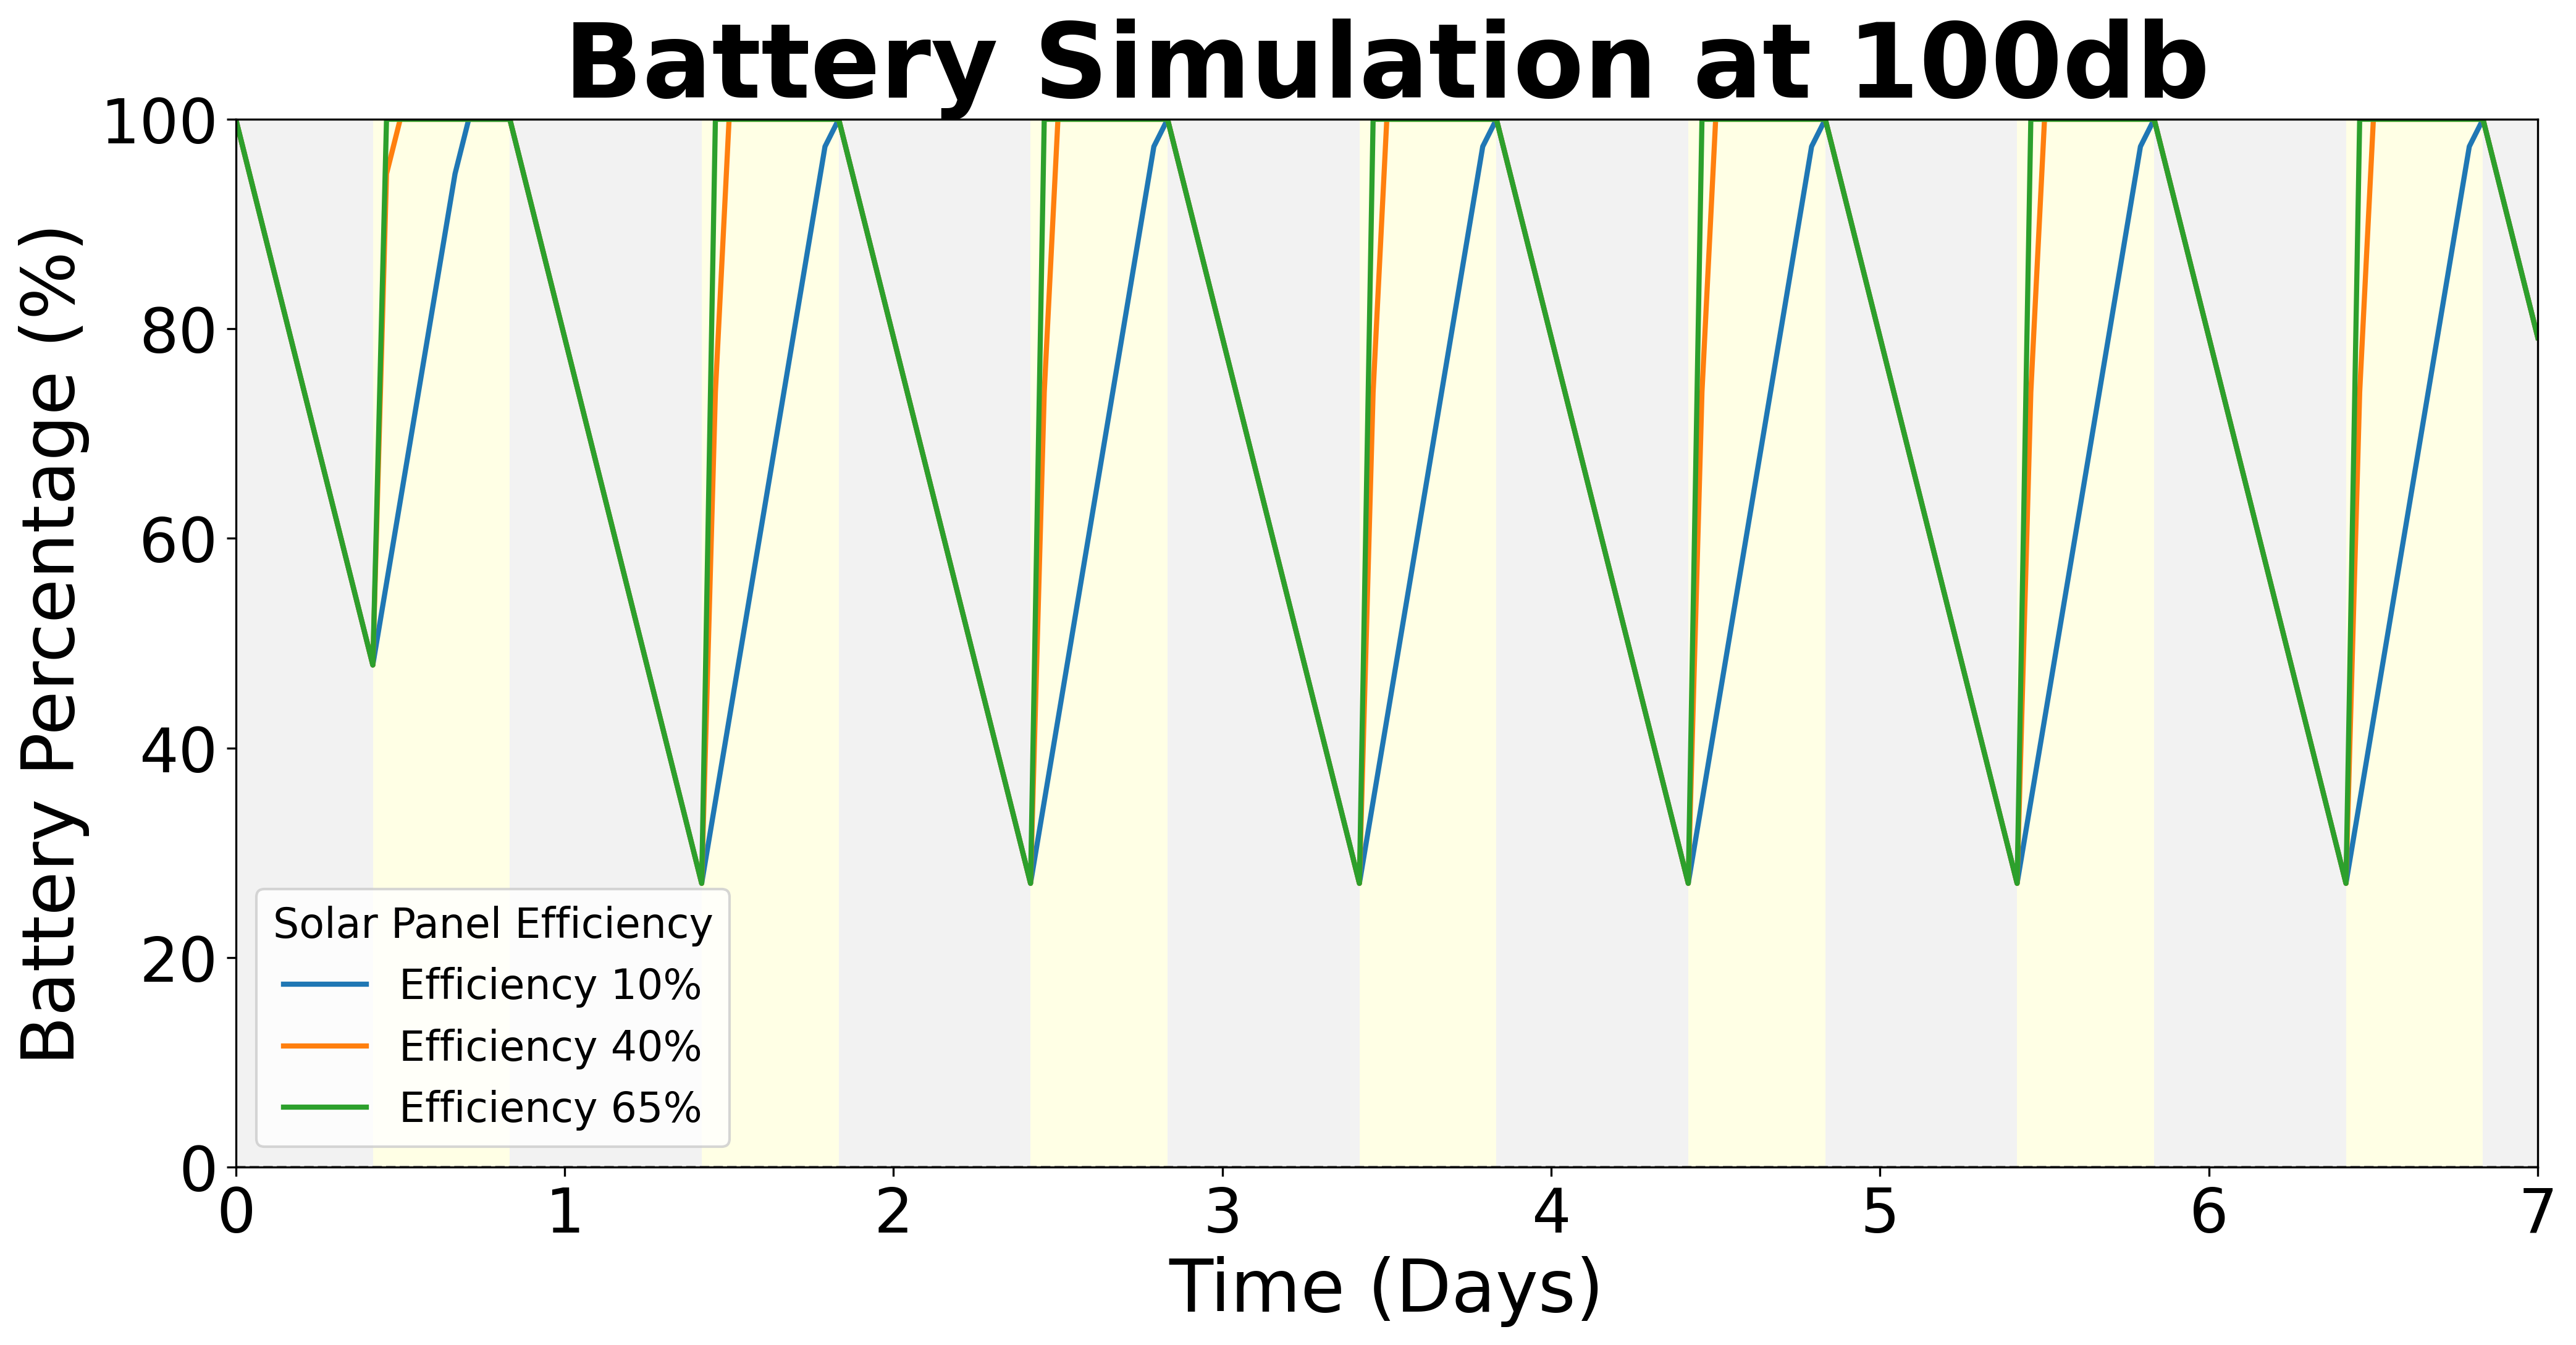

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Define base font size
font_size = 40

# Parameters
simulation_time_in_days = 7  # Simulation duration
battery_capacity = 76.8  # Wh
power_draw = 4  # W (constant power consumption)
solar_panel_power = 100  # W (solar panel output)

# Solar panel efficiencies to simulate
solar_efficiency_scenarios = [0.10, 0.40, 0.65] 

# Sunlight availability
sunlight_hours_per_day = 10  # Sunlight available for 6 hours every day
sunlight_start_hour = 10  # Sunlight starts at 10 AM
sunlight_hours = range(sunlight_start_hour, sunlight_start_hour + sunlight_hours_per_day)

# Calculate minimum solar efficiency required
energy_needed_per_day = power_draw * 24  # Wh
required_solar_efficiency = energy_needed_per_day / (solar_panel_power * sunlight_hours_per_day)
required_solar_efficiency = round(required_solar_efficiency, 4)
print(f"Minimum solar efficiency required to operate indefinitely: {required_solar_efficiency * 100}%")

# Simulation setup
hours_per_day = 24
total_hours = simulation_time_in_days * hours_per_day

# Initialize simulation results
results = {}

for efficiency in solar_efficiency_scenarios:
    current_battery = battery_capacity  # Start with a full battery
    battery_levels = [100]  # Battery percentage list

    for hour in range(total_hours):
        current_hour = hour % hours_per_day
        is_daytime = current_hour in sunlight_hours

        if is_daytime:
            # Daytime - solar panel provides energy
            solar_energy_hour = solar_panel_power * efficiency  # Wh
            net_energy = solar_energy_hour - power_draw
        else:
            # Nighttime - no solar energy
            net_energy = -power_draw

        # Update battery level
        current_battery += net_energy
        current_battery = min(max(current_battery, 0), battery_capacity)

        # Record battery percentage
        battery_levels.append((current_battery / battery_capacity) * 100)

    # Store results
    results[efficiency] = battery_levels

# Plotting
plt.figure(figsize=(14, 8), dpi=300)

# Add sunlight background
for day in range(simulation_time_in_days):
    plt.axvspan(day, day + sunlight_start_hour / 24, facecolor='gray', alpha=0.1)  # Night
    plt.axvspan(day + sunlight_start_hour / 24, day + (sunlight_start_hour + sunlight_hours_per_day) / 24, facecolor='yellow', alpha=0.1)  # Daytime
    plt.axvspan(day + (sunlight_start_hour + sunlight_hours_per_day) / 24, day + 1, facecolor='gray', alpha=0.1)  # Night

# Plot battery levels
for efficiency, battery_levels in results.items():
    plt.plot(
        np.linspace(0, simulation_time_in_days, total_hours + 1),
        battery_levels,
        label=f"Efficiency {int(efficiency * 100)}%",
        linewidth=2
    )

# Formatting the plot
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.title("Battery Simulation at 100db", fontsize=font_size, fontweight='bold')
plt.xlabel("Time (Days)", fontsize=font_size * 0.7)
plt.ylabel("Battery Percentage (%)", fontsize=font_size * 0.7)
plt.tick_params(axis='both', which='major', labelsize=font_size * 0.6)
plt.legend(title="Solar Panel Efficiency", fontsize=font_size * 0.4, title_fontsize=font_size * 0.4)
plt.xlim(0, simulation_time_in_days)
plt.ylim(0, 100)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

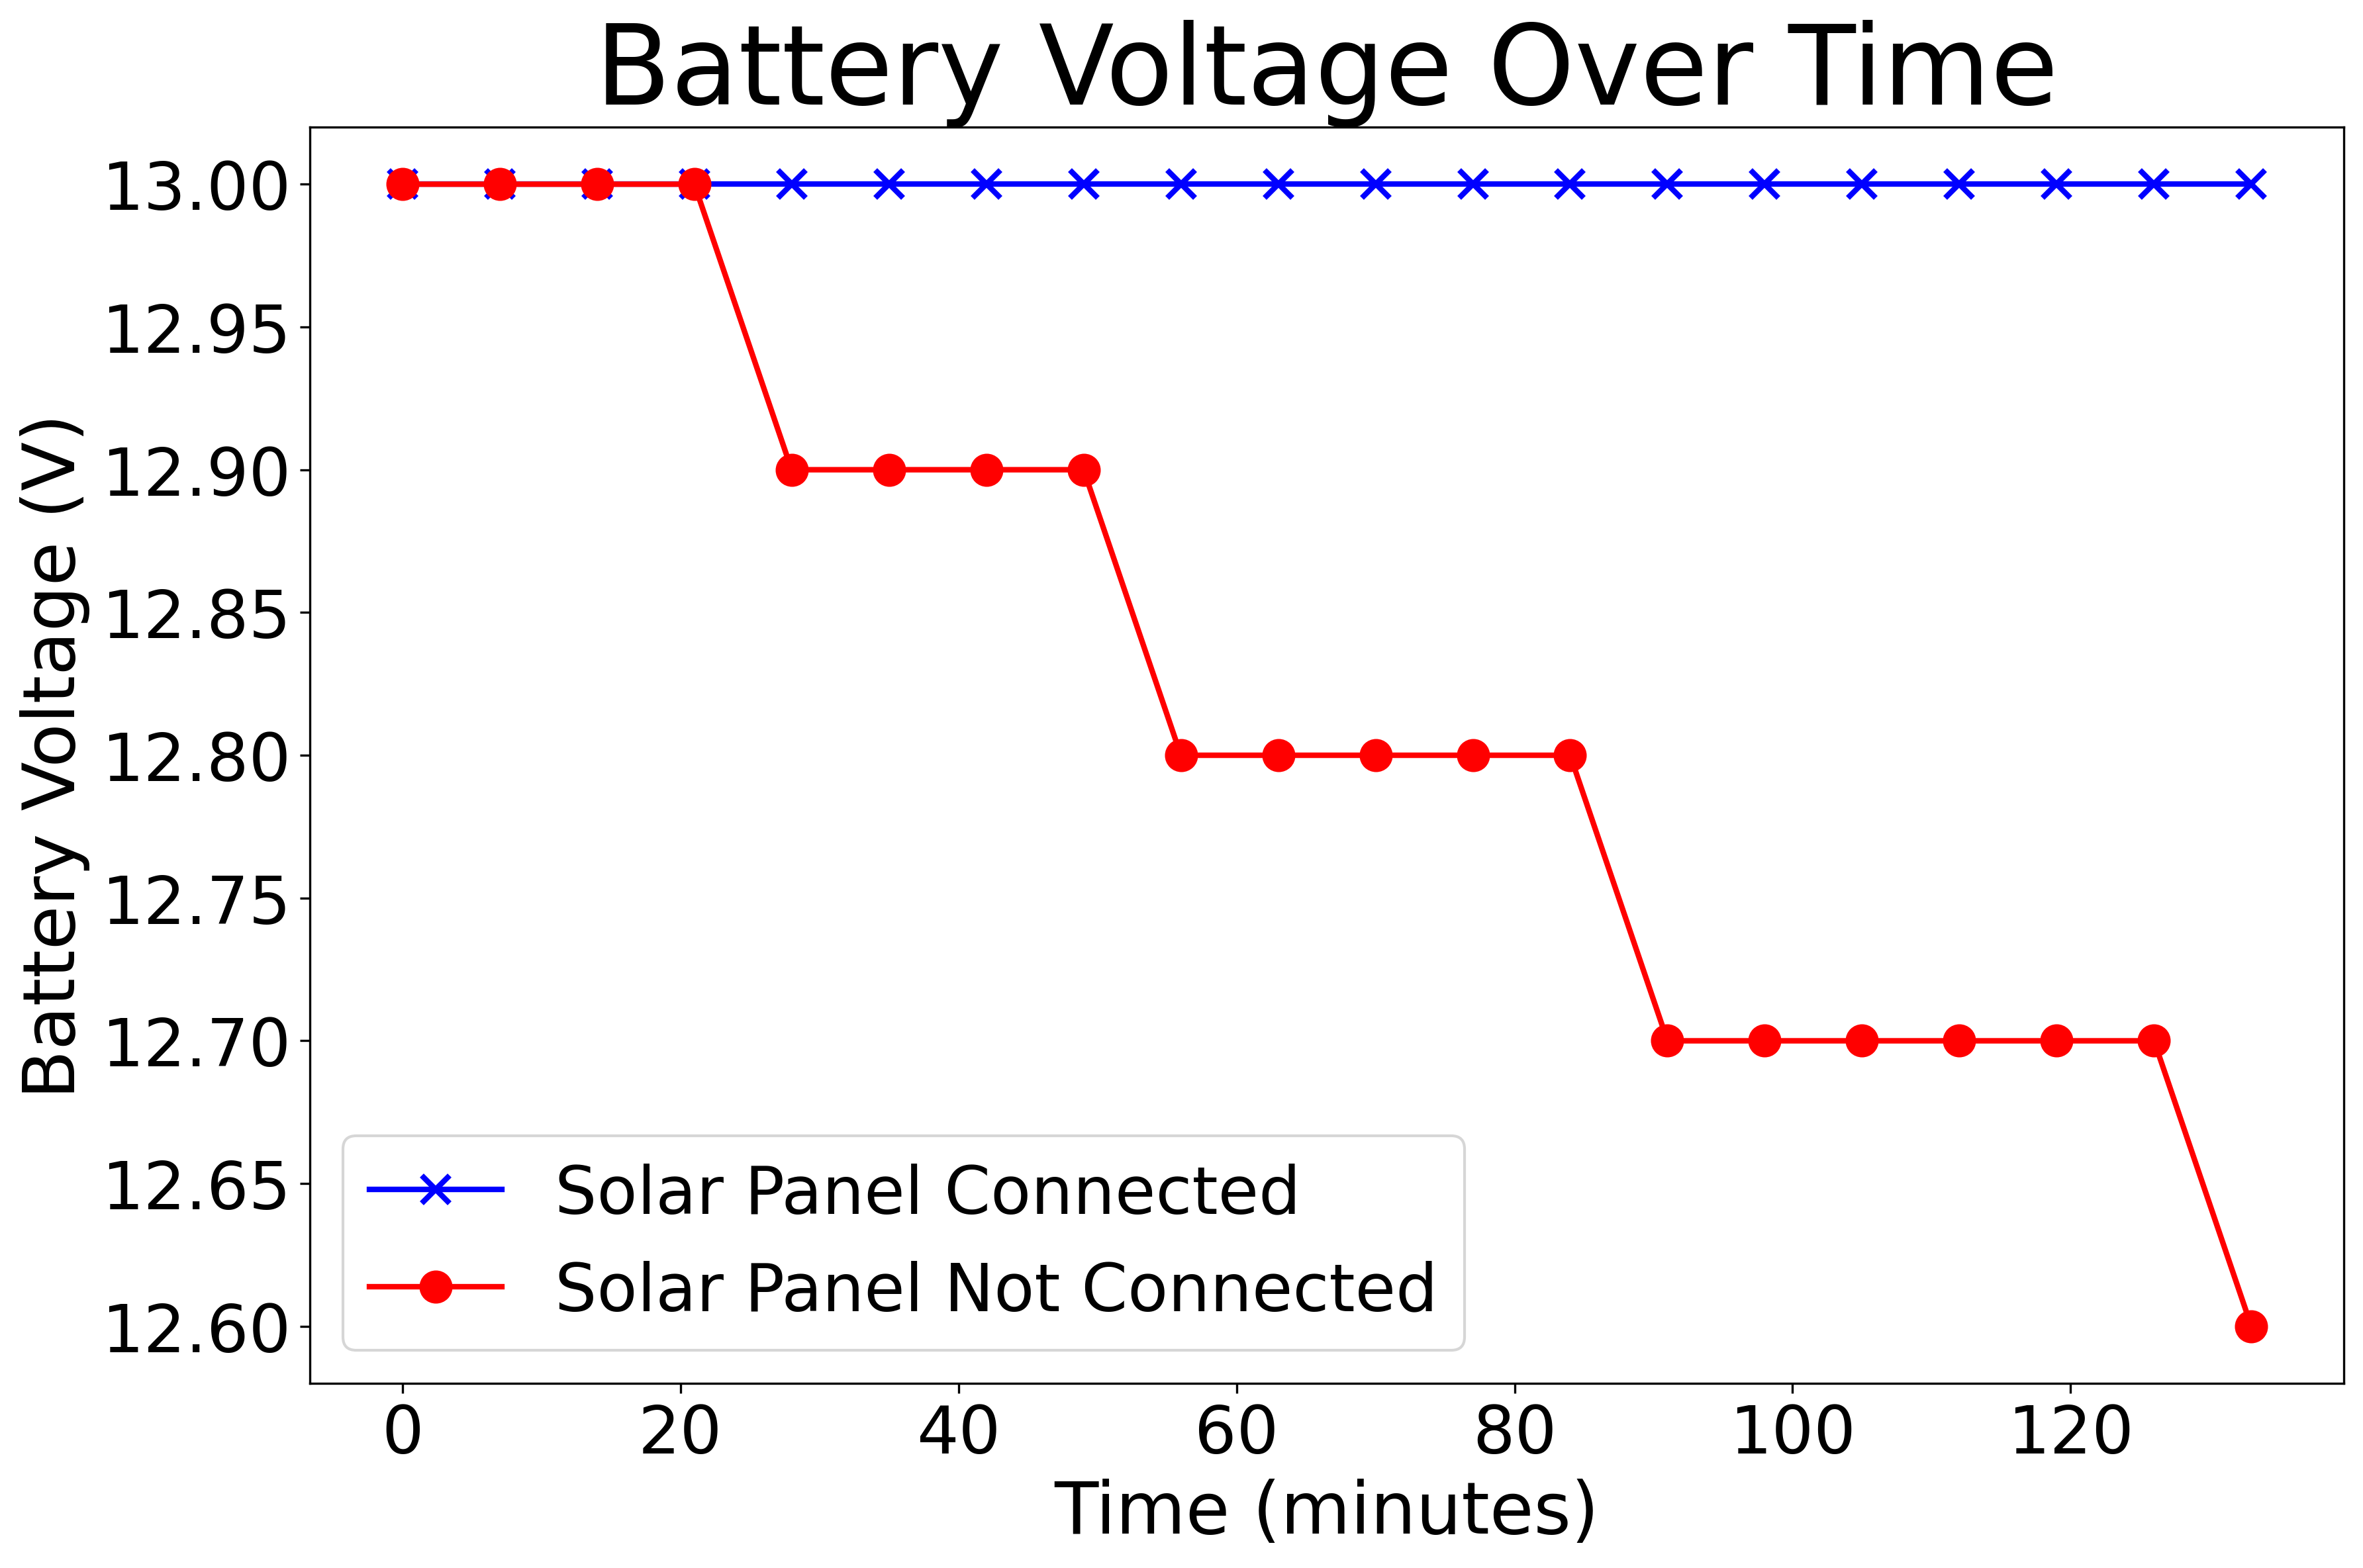

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Define base font size
font_size = 20

# Data for solar panel connected
solar_times_str = ['1:10', '1:17', '1:24', '1:31', '1:38', '1:45', '1:52', '1:59', 
                   '2:06', '2:13', '2:20', '2:27', '2:34', '2:41', '2:48', '2:55', 
                   '3:02', '3:09', '3:16', '3:23']
solar_voltages = [13]*len(solar_times_str)

# Data for solar panel not connected (120db continuous operation)
no_solar_times_str = ['3:30', '3:37', '3:44', '3:51', '3:58', '4:05', '4:12', '4:19', 
                      '4:26', '4:33', '4:40', '4:47', '4:54', '5:01', '5:08', '5:15', 
                      '5:22', '5:29', '5:36', '5:43']
no_solar_voltages = [13, 13, 13, 13, 12.9, 12.9, 12.9, 12.9, 12.8, 12.8, 12.8, 12.8, 
                     12.8, 12.7, 12.7, 12.7, 12.7, 12.7, 12.7, 12.6]

# Convert time strings to datetime objects
def convert_times(times_str):
    base_date = datetime(2024, 1, 1)  # Arbitrary date
    return [datetime.strptime(f"{base_date.date()} {t}", "%Y-%m-%d %H:%M") for t in times_str]

solar_times = convert_times(solar_times_str)
no_solar_times = convert_times(no_solar_times_str)

# Convert times to minutes since the first measurement
solar_minutes = [(t - solar_times[0]).total_seconds() / 60 for t in solar_times]
no_solar_minutes = [(t - no_solar_times[0]).total_seconds() / 60 for t in no_solar_times]

# Create the plot with publication-quality styling
plt.figure(figsize=(12, 8), dpi=300)

# Plot with interpolation
plt.plot(solar_minutes, solar_voltages, 'x-', color='blue', label='Solar Panel Connected', 
         linewidth=2, markersize=10, markeredgewidth=2)
plt.plot(no_solar_minutes, no_solar_voltages, 'o-', color='red', label='Solar Panel Not Connected', 
         linewidth=2, markersize=10, markeredgewidth=2)

# Styling for publication-quality graph
plt.title('Battery Voltage Over Time', fontsize=font_size * 2)
plt.xlabel('Time (minutes)', fontsize=font_size * 1.3)
plt.ylabel('Battery Voltage (V)', fontsize=font_size * 1.3)
plt.tick_params(axis='both', which='major', labelsize=font_size * 1.2)
plt.grid(False)
plt.legend(fontsize=font_size * 1.2)

# Adjust layout and add tight border
plt.tight_layout()

# # Save the plot
# plt.savefig('battery_voltage_comparison.png', bbox_inches='tight')

# Show the plot
plt.show()